# Testing: Inital LLM Agent

In [2]:
from app.agent import AIAgent
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

load_dotenv()

class City(BaseModel):
    name: str = Field(..., description="The name of the city")
    country: str = Field(..., description="The country where the city is located")


agent = AIAgent(api_key=os.getenv("OPENAI_API_KEY"),model='openai/gpt-4o-mini')
print(agent.ask("What is the capital of France?",response_model=City))

BadRequestError: Error code: 400 - {'error': {'message': "The requested model 'openai/gpt-4o-mini' does not exist.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_found'}}

# Testing the Superviosr Agent

In [ ]:
import pandas as pd
from app.structured_outputs.supervisor_structured_output import AnalysisPlan,AnalysisTask
from app.structured_outputs.context import DatasetContext
from app.prompt_templates.supervisor_prompt_template import supervisor_prompt_template
from app.agent import AIAgent
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from app.agents.supervisor import Supervisor
import os

load_dotenv()


df = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')
context = DatasetContext(
        file_path="data/churn.csv",
        dataset_description="Monthly churn snapshot for Q3 2024.",
        column_descriptions={
            "churn": "1 = churned (bad), 0 = retained",
            "credits": "Billing credits — high values indicate disputes",
            "plan_type": "Subscription tier: prepaid, postpaid, enterprise",
        },
        business_rules=[
            "credits: high = bad — indicates billing disputes or failures",
            "churn: 1 = bad outcome, 0 = good",
            "arpu: higher = better",
        ]
    )



supervisor = Supervisor(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',context_data=context)

# user_input = input("What do you want to know about the dataset? ")

raw,parsed_response,content = supervisor.run_task('What is causing the churn?')

print("response",parsed_response)



[Supervisor] supervisor needs clarification]
status='clarification' clarification_questions=['Could you please clarify the specific aspects of churn you are interested in? For example, are you looking for correlations with billing credits or differences across plan types?'] tasks=[] reasoning="The user's input is unclear and does not specify what they mean by 'causing the churn'. A specific aspect or metric related to churn needs to be defined."
  1. Could you please clarify the specific aspects of churn you are interested in? For example, are you looking for correlations with billing credits or differences across plan types?
response status='plan' clarification_questions=[] tasks=[AnalysisTask(agent='coder', task_description='Analyze the relationship between billing credits and churn. Calculate the average billing credits for churned (churn = 1) and retained (churn = 0) customers. Output a DataFrame with the average credits for both groups.', depends_on=[]), AnalysisTask(agent='visua

# Testing: Coder Agent

In [ ]:
import pandas as pd
from app.agents.coder import Coder
from app.structured_outputs.coder_structured_output import CoderResponse
from app.structured_outputs.context import DatasetContext
from app.prompt_templates.coder_prompt_template import coder_prompt_template
from app.agent import AIAgent
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

load_dotenv()

df = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')
context = DatasetContext(
        file_path="/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv",
        dataset_description="Monthly churn snapshot for Q3 2024.",
        column_descriptions={
            "churn": "1 = churned (bad), 0 = retained",
            "credits": "Billing credits — high values indicate disputes",
            "plan_type": "Subscription tier: prepaid, postpaid, enterprise",
        },
        business_rules=[
            "credits: high = bad — indicates billing disputes or failures",
            "churn: 1 = bad outcome, 0 = good",
            "arpu: higher = better",
        ]
    )


coder = Coder(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',max_retries=3)

parsed_response,content = coder.run_task(current_task="Check for null values in the 'credits' and 'churn' columns and handle them appropriately.",context_data=context)

print(content)
for info in parsed_response:
    print(info)



🔄 Attempt 1/3
✅ Attempt 1 succeeded.
Null values in 'credits': 0
Null values in 'churn': 0
Null values in 'credits' after handling: 0
Null values in 'churn' after handling: 0

('thought_process', 'I will first load the dataset and check for null values in the specified columns to ensure data integrity before handling any missing values.')
('executable_code', 'import pandas as pd\n\ndf = pd.read_csv("/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv")\n\n# Check for null values in \'credits\' and \'churn\' columns\nnull_credits = df[\'credits\'].isnull().sum()\nnull_churn = df[\'churn\'].isnull().sum()\n\nprint(f"Null values in \'credits\': {null_credits}")\nprint(f"Null values in \'churn\': {null_churn}")\n\n# Handle null values: fill \'credits\' with 0 (no disputes) and \'churn\' with mode (0 or 1)\ndf[\'credits\'] = df[\'credits\'].fillna(0)\ndf[\'churn\'] = df[\'churn\'].fillna(df[\'churn\'].mode()[0])\n\n# Confirm handling of nulls\nnull_credits_after = df[\'c

# Testing Sup -> Coder

In [ ]:
import pandas as pd
from app.structured_outputs.context import DatasetContext
from dotenv import load_dotenv
from app.agents.supervisor import Supervisor
import os
from app.agents.orchestrator import AnalysisOrchestrator
load_dotenv()


df = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')
context = DatasetContext(
        file_path='/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv',
        dataset_description="Monthly churn snapshot for Q3 2024.",
        column_descriptions={
            "churn": "1 = churned (bad), 0 = retained",
            "credits": "Billing credits — high values indicate disputes",
            "plan_type": "Subscription tier: prepaid, postpaid, enterprise",
        },
        business_rules=[
            "credits: high = bad — indicates billing disputes or failures",
            "churn: 1 = bad outcome, 0 = good",
            "arpu: higher = better",
        ]
    )

supervisor = Supervisor(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',context_data=context)
orchestrator = AnalysisOrchestrator(supervisor,api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',max_retries=3,dataset_context=context)
orchestrator.execute_plan(user_questions=["What is causing the churn?"])


[Supervisor] supervisor needs clarification]
status='clarification' clarification_questions=['What specific factors or metrics related to churn are you interested in analyzing? For example, would you like to look at the influence of billing credits, plan type, or perhaps a combination of these?'] tasks=[] reasoning='The question about what is causing churn is too broad and requires clarification on which specific factors the user wants to explore.'
  1. What specific factors or metrics related to churn are you interested in analyzing? For example, would you like to look at the influence of billing credits, plan type, or perhaps a combination of these?
[Supervisor]
Here is my plan:
  - coder task: Calculate the correlation between billing credits and churn status. Use the 'credits' column for billing credits and 'churn' column to determine churn status. Provide the correlation coefficient and a summary of the relationship. (depends on [])
  - visualizer task: Create a scatter plot to v

'Analysis failed or was incomplete.'

# Testing -> Sup -> Agents

In [ ]:
import pandas as pd
from app.structured_outputs.context import DatasetContext
from dotenv import load_dotenv
from app.agents.supervisor import Supervisor
import os
from app.agents.orchestrator import AnalysisOrchestrator
load_dotenv()


df = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')
context = DatasetContext(
        file_path='/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv',
        dataset_description="Monthly churn snapshot for Q3 2024.",
        column_descriptions={
            "churn": "1 = churned (bad), 0 = retained",
            "credits": "Billing credits — high values indicate disputes",
            "plan_type": "Subscription tier: prepaid, postpaid, enterprise",
        },
        business_rules=[
            "credits: high = bad — indicates billing disputes or failures",
            "churn: 1 = bad outcome, 0 = good",
            "arpu: higher = better",
        ]
    )

supervisor = Supervisor(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',temperature=0.3)
orchestrator = AnalysisOrchestrator(supervisor,api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',max_retries=3,dataset_context=context)
orchestrator.execute_plan(user_questions=["Is there a correlation between 'credits' and 'churn'?"])

[Orchestrator] Sending user questions to Supervisor for planning...
[Supervisor]
Here is my plan:
  - coder task: Calculate the correlation coefficient between 'credits' (Continuous) and 'churn' (Binary). (depends on [])
  - visualizer task: Visualize the relationship between 'credits' (Continuous) and 'churn' (Binary). The visual must demonstrate the distribution of credits across churned vs. retained groups. (depends on [0])

[Orchestrator] Plan finalized. Executing 2 tasks.

--- [Task 0] Agent: coder ---

🔄 Attempt 1/3
✅ Attempt 1 succeeded.
[Coder]
Here are my results:
Null values in credits: 0
Null values in churn: 0
Correlation coefficient between credits and churn: 0.041692393892930724

The correlation coefficient of approximately 0.04 indicates a very weak positive relationship between billing credits and customer churn, suggesting that higher billing disputes are not strongly associated with increased customer loss. 

--- [Task 1] Agent: visualizer ---

--- [Visualizer] Attemp

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



✅ Visualization saved successfully.
[Visualizer]
Insight: ```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')

# Set the aesthetics for the plot
sns.set(style="whitegrid")

# Create a Box Plot to visualize the distribution of credits across churned vs. retained groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='credits', data=data, palette='viridis')

# Set title and labels
plt.title('Very Weak Positive Relationship: Distribution of Credits by Churn Status', fontsize=16)
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Billing Credits', fontsize=12)

# Finalize the plot
plt.tight_layout()
plt.savefig('credits_vs_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.close('all')
```

No clear relationship was found between billing credits and customer churn, as indicated by the very weak positive co

(VisualizerOutput(executable_code="import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Load the dataset\nchurn_data = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')\n\n# Set the visual style\nsns.set(style='whitegrid')\n\n# Create a Box Plot to show the distribution of credits across churned and retained groups\nplt.figure(figsize=(10, 6))\nsns.boxplot(x='churn', y='credits', data=churn_data, palette='viridis')\nplt.title('Distribution of Billing Credits by Churn Status')\nplt.xlabel('Churn Status (0 = Retained, 1 = Churned)')\nplt.ylabel('Billing Credits')\nplt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])\nplt.tight_layout()\nplt.savefig('credits_vs_churn_distribution.png', dpi=300, bbox_inches='tight')\nplt.close('all')", results_interpretation='```python\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Load the dataset\ndata = pd.read_csv(\'/Users/theodoreleeiv/Documents/GitH

In [ ]:
print(orchestrator.dataset_context)
print('------------------')
print(orchestrator.user_questions)
print('------------------')
print(orchestrator.task_results)
print('------------------')
print(orchestrator.plan)    
print('------------------') 
print(orchestrator.analysis_goal)

file_path='/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv' dataset_description='Monthly churn snapshot for Q3 2024.' column_descriptions={'churn': '1 = churned (bad), 0 = retained', 'credits': 'Billing credits — high values indicate disputes', 'plan_type': 'Subscription tier: prepaid, postpaid, enterprise'} business_rules=['credits: high = bad — indicates billing disputes or failures', 'churn: 1 = bad outcome, 0 = good', 'arpu: higher = better'] sensitivity=None known_issues=[]
------------------
["Is there a correlation between 'credits' and 'churn'?"]
------------------
{0: (CoderResponse(thought_process="I need to calculate the correlation between the 'credits' and 'churn' columns to understand their relationship, and I'll use the pandas method df['credits'].corr(df['churn']) after checking for null values.", executable_code="import pandas as pd\n\ndf = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')\n\n# Check for nulls 

# Testing -> Sup -> Agents -> Reporter

In [1]:
import pandas as pd
from app.structured_outputs.context import DatasetContext
from dotenv import load_dotenv
from app.agents.supervisor import Supervisor
import os
from app.agents.orchestrator import AnalysisOrchestrator
from app.agents.reporter import Reporter
from app.agents.auditor import Evaluator
load_dotenv()


df = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')
context = DatasetContext(
        file_path='/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv',
        dataset_description="Monthly churn snapshot for Q3 2024.",
        column_descriptions={
            "churn": "1 = churned (bad), 0 = retained",
            "credits": "Billing credits — high values indicate disputes",
            "plan_type": "Subscription tier: prepaid, postpaid, enterprise",
        },
        business_rules=[
            "credits: high = bad — indicates billing disputes or failures",
            "churn: 1 = bad outcome, 0 = good",
            "arpu: higher = better",
        ]
    )

supervisor = Supervisor(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',temperature=0.3)
reporter = Reporter(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',temperature=0.6)
evaluator = Evaluator(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',temperature=0.3)
orchestrator = AnalysisOrchestrator(supervisor,reporter=reporter,evaluator=evaluator,api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',max_retries=3,dataset_context=context)
orchestrator.execute_plan(user_questions=["Is there a correlation between 'credits' and 'churn'?"])

[Orchestrator] Sending user questions to Supervisor for planning...

[Supervisor] Phase 1: Strategic Alignment
[Supervisor]
Here is my plan:
  - coder task: Calculate the correlation coefficient between 'credits' (Continuous) and 'churn' (Binary). (depends on [] - Addresses question: 'Is there a correlation between 'credits' and 'churn'?')
  - visualizer task: Visualize the relationship between 'credits' (Continuous) and 'churn' (Binary). The visual must demonstrate the distribution of credits across churned vs. retained groups. (depends on [0] - Addresses question: 'Is there a correlation between 'credits' and 'churn'?')

[Orchestrator] Plan finalized. Executing 2 tasks.

--- [Task 0] Agent: coder ---

🔄 Attempt 1/3
✅ Attempt 1 succeeded.
[Coder]
Here are my results:
Null values in credits: 0, Null values in churn: 0
Dropped rows with null values.
Correlation between credits and churn: 0.041692393892930724

The correlation coefficient of 0.0417 suggests a very weak positive relationsh

<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



✅ Visualization saved successfully.
[Visualizer]
Insight: ```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv')

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a Box Plot to visualize the distribution of credits across churned vs. retained groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='credits', data=data, palette='viridis')

# Set title and labels
plt.title('No Clear Relationship Found Between Billing Credits and Churn', fontsize=16)
plt.xlabel('Churn (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Billing Credits', fontsize=12)

# Remove top and right borders
sns.despine()

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig('/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/app/ai_output_imgs/credits_vs_churn.png', dpi=300, bbox_inches='tight')

# Close the plot to free mem

{'user_question': "Is there a correlation between 'credits' and 'churn'?",
 'agent': 'visualizer',
 'instruction': "Visualize the relationship between 'credits' (Continuous) and 'churn' (Binary). The visual must demonstrate the distribution of credits across churned vs. retained groups.",
 'execution_output': (VisualizerOutput(executable_code="import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Load the dataset\nfile_path = '/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv'\ndf = pd.read_csv(file_path)\n\n# Set the visual style\nsns.set(style='whitegrid')\n\n# Create a box plot to show the distribution of credits across churned vs. retained\nplt.figure(figsize=(10, 6))\nsns.boxplot(x='churn', y='credits', data=df, palette='viridis')\n\n# Title and labels\ntitle = 'Distribution of Billing Credits by Churn Status'\nplt.title(title, fontsize=16)\nplt.xlabel('Churn Status (0 = Retained, 1 = Churned)', fontsize=12)\nplt.ylabel('Billing Cred

In [ ]:
print(orchestrator.dataset_context)
print('------------------')
print(orchestrator.enriched_task_results)
print('------------------')
print(orchestrator.task_results)
print('------------------')
print(orchestrator.plan)
print('------------------') 
print(orchestrator.analysis_goal)

file_path='/Users/theodoreleeiv/Documents/GitHub/AI-DATA-ASSISTANT/data/churn.csv' dataset_description='Monthly churn snapshot for Q3 2024.' column_descriptions={'churn': '1 = churned (bad), 0 = retained', 'credits': 'Billing credits — high values indicate disputes', 'plan_type': 'Subscription tier: prepaid, postpaid, enterprise'} business_rules=['credits: high = bad — indicates billing disputes or failures', 'churn: 1 = bad outcome, 0 = good', 'arpu: higher = better'] sensitivity=None known_issues=[]
------------------
[{'task_index': 0, 'agent': 'coder', 'original_question': None, 'instruction': "Calculate the correlation coefficient between 'credits' (Continuous) and 'churn' (Binary).", 'result': 'No result produced due to execution error.', 'was_successful': False}, {'task_index': 1, 'agent': 'visualizer', 'original_question': None, 'instruction': "Visualize the relationship between 'credits' (Continuous) and 'churn' (Binary). The visual must demonstrate the distribution of credits

In [2]:
# Reporter 
reporter = Reporter(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini',temperature=0.3)
report = reporter.run_task(orchestrator.analysis_goal,orchestrator.task_results,orchestrator.dataset_context)

In [4]:
from app.agents.auditor import Evaluator
from app.structured_outputs.evaluator_structured_output import AuditResult

auditor = Evaluator(api_key=os.getenv("OPENAI_API_KEY"),model='gpt-4o-mini')
audit_result = auditor.audit(user_questions=orchestrator.user_questions, task_outputs=orchestrator.task_results,context_data=orchestrator.dataset_context)
print(audit_result)

is_passed=False logical_conflicts=["Task 0 states a correlation of 0.0417, indicating a very weak positive relationship, while Task 1 claims 'No clear relationship was found' without referencing the weak correlation value.", "Task 1's interpretation suggests a lack of relationship, which contradicts Task 0's weak positive correlation result."] technical_errors=[] missing_answers=[] recommendation_for_supervisor="Task 1 should reference the correlation result from Task 0 to provide a more accurate interpretation of the relationship between 'credits' and 'churn'. The visualizer should acknowledge the weak correlation value rather than stating there is no clear relationship."


# Testing Supervisor Agent

In [ ]:
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage
load_dotenv("config/.env")

from context import DatasetContext
from agents.supervisor_agent import run_supervisor
from structured_outputs import SupervisorOutput, SupervisorAction

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description="Monthly snapshot of active mobile subscribers Q3 2024.",
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=["enterprise segment has only ~30 records — small sample"]
)


def test_vague_question():
    """Vague question should return CLARIFY."""
    print("\n" + "="*60)
    print("TEST 1 — Vague question")
    print("="*60)
    result = run_supervisor(user_message="can you look at my data", context=context)
    print(f"Action:    {result.action}")
    print(f"Reasoning: {result.reasoning}")
    if result.is_clarify():
        print(f"Question:  {result.clarifying_question}")
        print("✓ PASS")
    else:
        print(f"Improved:  {result.improved_questions}")
        print("✗ FAIL — expected CLARIFY")


def test_single_clear_question():
    """Single clear question should return HANDOFF with one improved question."""
    print("\n" + "="*60)
    print("TEST 2 — Single clear question")
    print("="*60)
    result = run_supervisor(
        user_message="what is the churn rate for each plan type",
        context=context,
    )
    print(f"Action: {result.action}")
    if result.is_handoff():
        print(f"Improved questions: {result.improved_questions}")
        assert len(result.improved_questions) == 1
        assert "churn" in result.improved_questions[0].lower()
        assert "plan_type" in result.improved_questions[0].lower()
        print("✓ PASS")
    else:
        print(f"Question: {result.clarifying_question}")
        print("✗ FAIL — expected HANDOFF")


def test_multiple_questions():
    """Multiple questions should all be improved and returned as a list."""
    print("\n" + "="*60)
    print("TEST 3 — Multiple questions")
    print("="*60)
    result = run_supervisor(
        user_message=(
            "1. What is the churn rate by plan type?\n"
            "2. Is there a significant difference in arpu between churned and retained customers?\n"
            "3. Which customers have the highest credits values?"
        ),
        context=context,
    )
    print(f"Action: {result.action}")
    if result.is_handoff():
        print(f"Improved questions ({len(result.improved_questions)}):")
        for i, q in enumerate(result.improved_questions, 1):
            print(f"  {i}. {q}")
        assert len(result.improved_questions) == 3, \
            f"Expected 3 questions, got {len(result.improved_questions)}"
        print("✓ PASS")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected HANDOFF")


def test_multi_turn():
    """Second message resolves to HANDOFF after clarification."""
    print("\n" + "="*60)
    print("TEST 4 — Multi-turn conversation")
    print("="*60)
    result1 = run_supervisor(user_message="analyse my data", context=context)
    print(f"Turn 1 — {result1.action}")
    if result1.is_clarify():
        print(f"Question: {result1.clarifying_question}")

    history = [
        HumanMessage(content="analyse my data"),
        AIMessage(content=result1.clarifying_question or ""),
    ]
    result2 = run_supervisor(
        user_message="I want to know which plan type has the highest churn rate",
        context=context,
        conversation_history=history,
    )
    print(f"Turn 2 — {result2.action}")
    if result2.is_handoff():
        print(f"Improved: {result2.improved_questions}")
        print("✓ PASS")
    else:
        print(f"Still clarifying: {result2.clarifying_question}")
        print("✗ FAIL")


if __name__ == "__main__":
    test_vague_question()
    test_single_clear_question()
    test_multiple_questions()
    test_multi_turn()


TEST 1 — Vague question
Action:    SupervisorAction.CLARIFY
Reasoning: The request to 'look at my data' is vague and does not specify what analysis or insight is desired.
Question:  What specific analysis or insights are you looking for from the data?
✓ PASS

TEST 2 — Single clear question
Action: SupervisorAction.HANDOFF
Improved questions: ["What is the churn rate for each 'plan_type' in the dataset, calculated as the number of churned users divided by the total number of users for each plan type?"]
✓ PASS

TEST 3 — Multiple questions
Action: SupervisorAction.HANDOFF
Improved questions (3):
  1. What is the churn rate calculated as the percentage of churned customers by each plan_type?
  2. Is there a statistically significant difference in arpu between customers with churn = 1 and churn = 0?
  3. Which customers have the highest credits values, indicating potential billing disputes or service failures?
✓ PASS

TEST 4 — Multi-turn conversation
Turn 1 — SupervisorAction.CLARIFY
Quest

# Testing Planner Agent


In [ ]:
"""
Note: These tests require a real CSV file at the path in DatasetContext.
Create a small test CSV before running:
"""

import pandas as pd, numpy as np
pd.DataFrame({
    "churn":         np.random.binomial(1, 0.2, 100),
    "arpu":          np.random.normal(55, 15, 100).clip(5),
    "tenure_months": np.random.randint(1, 60, 100),
    "plan_type":     np.random.choice(["prepaid","postpaid","enterprise"], 100),
    "credits":       np.random.exponential(10, 100)
}).to_csv("data/churn.csv", index=False)

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv("config/.env")

from context import DatasetContext
from agents.planner_agent import run_planner
from structured_outputs import PlannerOutput, PlannerAction, AgentType


# ── Create test CSV if it doesn't exist ──────────────────────────────────────

def _ensure_test_csv():
    path = Path("data/churn.csv")
    if not path.exists():
        path.parent.mkdir(exist_ok=True)
        np.random.seed(42)
        n = 200
        pd.DataFrame({
            "churn":         np.random.binomial(1, 0.2, n),
            "arpu":          np.random.normal(55, 15, n).clip(5),
            "tenure_months": np.random.randint(1, 60, n),
            "plan_type":     np.random.choice(
                                 ["prepaid", "postpaid", "enterprise"], n,
                                 p=[0.5, 0.35, 0.15]
                             ),
            "credits":       np.random.exponential(10, n),
        }).to_csv(path, index=False)
        print(f"Created test CSV at {path}")


# ── Shared context ────────────────────────────────────────────────────────────

_ensure_test_csv()

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


# ── Tests ─────────────────────────────────────────────────────────────────────

def test_produces_plan():
    """A clear question should produce a PLAN with steps."""
    print("\n" + "="*60)
    print("TEST 1 — Produces a plan")
    print("="*60)

    result = run_planner(
        improved_question=(
            "What is the churn rate (proportion where churn = 1) broken "
            "down by plan_type? Which segment has the highest churn rate?"
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        print(f"Goal:   {result.goal}")
        print(f"Steps:  {len(result.steps)}")
        for step in result.steps:
            print(f"  Step {step.id} [{step.agent.value}] — {step.title}")
        print(f"Risks:  {result.risks}")
        print("✓ PASS")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected PLAN")


def test_plan_has_correct_agents():
    """
    A question requiring computation and visualization should assign
    the right agents to the right steps.
    """
    print("\n" + "="*60)
    print("TEST 2 — Correct agents assigned")
    print("="*60)

    result = run_planner(
        improved_question=(
            "What is the churn rate by plan_type? "
            "Show the result as a bar chart."
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        for step in result.steps:
            print(f"  Step {step.id} [{step.agent.value}] — {step.title}")

        agents_used = {step.agent for step in result.steps}
        has_coder  = AgentType.CODER      in agents_used
        has_viz    = AgentType.VISUALIZER in agents_used

        print(f"\nHas coder step:      {'✓' if has_coder else '✗'}")
        print(f"Has visualizer step: {'✓' if has_viz   else '✗'}")
        print("✓ PASS" if has_coder and has_viz else "✗ FAIL")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")
        print("✗ FAIL — expected PLAN")


def test_plan_references_real_columns():
    """
    Steps should reference actual column names from the dataset,
    not generic placeholders.
    """
    print("\n" + "="*60)
    print("TEST 3 — Steps reference real column names")
    print("="*60)

    result = run_planner(
        improved_question=(
            "Is there a significant difference in arpu between "
            "churned (churn=1) and retained (churn=0) customers?"
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        all_inputs = []
        for step in result.steps:
            all_inputs.extend(step.inputs)
            print(f"  Step {step.id} inputs: {step.inputs}")

        has_churn = any("churn" in i.lower() for i in all_inputs)
        has_arpu  = any("arpu"  in i.lower() for i in all_inputs)

        print(f"\nInputs reference 'churn': {'✓' if has_churn else '✗'}")
        print(f"Inputs reference 'arpu':  {'✓' if has_arpu  else '✗'}")
        print("✓ PASS" if has_churn and has_arpu else "✗ FAIL")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")


def test_business_rules_in_steps():
    """
    Steps involving the credits column should carry the business rule note.
    """
    print("\n" + "="*60)
    print("TEST 4 — Business rules in relevant steps")
    print("="*60)

    result = run_planner(
        improved_question=(
            "Which customers have the highest credits values? "
            "Note that high credits indicate billing disputes (bad signal)."
        ),
        context=context,
    )

    print(f"Action: {result.action}")

    if result.is_plan():
        for step in result.steps:
            print(f"  Step {step.id} — {step.title}")
            print(f"    business_rule_notes: {step.business_rule_notes}")

        has_rule = any(
            step.business_rule_notes and
            ("credit" in step.business_rule_notes.lower() or
             "bad"    in step.business_rule_notes.lower())
            for step in result.steps
        )
        print(f"\nBusiness rule in a step: {'✓' if has_rule else '✗'}")
    else:
        print(f"Got CLARIFY: {result.clarifying_question}")


if __name__ == "__main__":
    test_produces_plan()
    test_plan_has_correct_agents()
    test_plan_references_real_columns()
    test_business_rules_in_steps()


TEST 1 — Produces a plan


KeyboardInterrupt: 

# Testing: Supervisor -> Planner Communication

In [ ]:


from dotenv import load_dotenv
load_dotenv("config/.env")

from langgraph.types import Command

from context import DatasetContext
from workflow.state import AgentState
from workflow.graph import build_graph


# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


def test_supervisor_to_planner():
    """
    Full flow: user question → supervisor → planner → human_approval interrupt.
    Verifies the graph pauses at human_approval with the plan.
    """
    print("\n" + "="*60)
    print("TEST 1 — Supervisor → Planner → Human approval interrupt")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-1"}}

    # Initial invocation
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type?"}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
            "planner_clarification": None,   # ← add this
        },
        config=config,
        version="v2",
    )

    print(f"Result type: {type(result).__name__}")

    # Should have paused at human_approval
    if hasattr(result, "interrupts") and result.interrupts:
        interrupt_payload = result.interrupts[0].value
        print(f"Interrupted with: {interrupt_payload['message']}")
        plan_data = interrupt_payload.get("plan")
        if plan_data:
            print(f"Plan goal: {plan_data.get('goal')}")
            print(f"Steps: {len(plan_data.get('steps', []))}")
            for step in plan_data.get("steps", []):
                print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        print("✓ PASS — graph paused at human_approval")
    else:
        print(f"Result value: {result}")
        print("✗ FAIL — expected interrupt at human_approval")


def test_approve_and_execute():
    """
    Full flow including human approval and placeholder execution.
    """
    print("\n" + "="*60)
    print("TEST 2 — Approve plan and execute steps")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-2"}}

    # First invocation — runs to interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type? Show as a bar chart."}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print("✗ FAIL — expected interrupt, got:", result)
        return

    print(f"Plan received — approving...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": result.interrupts[0].value.get("plan")}),
        config=config,
        version="v2",
    )

    print(f"Final result type: {type(final_result).__name__}")

    # Get final state
    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"Final report: {state.get('final_report')}")
        print(f"Step results: {state.get('step_results')}")
        if state.get("final_report"):
            print("✓ PASS — workflow completed")
        else:
            print("✗ FAIL — no final report")


def test_vague_question_clarification():
    """
    Vague question should trigger clarification — graph pauses at END
    waiting for user response.
    """
    print("\n" + "="*60)
    print("TEST 3 — Vague question triggers clarification")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-3"}}

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "analyse my data"}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    state = result.value if hasattr(result, "value") else result
    if isinstance(state, dict):
        messages = state.get("messages", [])
        last_msg = messages[-1] if messages else None
        if last_msg:
            content = getattr(last_msg, "content", str(last_msg))
            print(f"Last message: {content}")
            print("✓ PASS — supervisor asked for clarification")


if __name__ == "__main__":
    test_supervisor_to_planner()
    test_approve_and_execute()
    test_vague_question_clarification()



TEST 1 — Supervisor → Planner → Human approval interrupt

[Supervisor] Original question: What is the churn rate by plan type?
[Supervisor] Improved questions:
  1. What is the churn rate, defined as the percentage of churned customers, grouped by the 'plan_type' column?
[Planner] Plan ready — 3 steps
Result type: GraphOutput
Interrupted with: Please review the analysis plan.
Plan goal: Calculate the churn rate grouped by plan type in the churn dataset.
Steps: 3
  Step 1 [AgentType.CODER] — Compute churn rate by plan_type
  Step 2 [AgentType.VISUALIZER] — Visualize churn rate by plan_type
  Step 3 [AgentType.REPORTER] — Compile final report
✓ PASS — graph paused at human_approval

TEST 2 — Approve plan and execute steps

[Supervisor] Original question: What is the churn rate by plan type? Show as a bar chart.
[Supervisor] Improved questions:
  1. What is the churn rate (percentage of churned customers) by plan type (prepaid, postpaid, enterprise)? Please present the results as a bar c

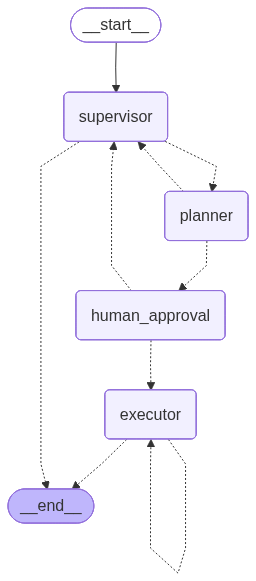

In [ ]:
from IPython.display import Image, display
graph = build_graph(context=context)
display(Image(graph.get_graph().draw_mermaid_png()))

# Testing - Coder Agent

In [ ]:
"""
tests/test_coder.py

Tests for the coder agent.

Run from project root:
    python -m tests.test_coder
"""

from dotenv import load_dotenv
load_dotenv("config/.env")

from context import DatasetContext
from structured_outputs.planner_output import AnalysisStep
from structured_outputs.base import AgentType
from agents.coder_agent import run_coder


context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description="Monthly snapshot of active mobile subscribers Q3 2024.",
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=["enterprise segment has only ~30 records — small sample"]
)


def test_churn_rate_by_plan():
    """Coder should compute churn rate grouped by plan_type."""
    print("\n" + "="*60)
    print("TEST 1 — Churn rate by plan type")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Compute churn rate by plan type",
        description=(
            "Group customers by plan_type and compute the churn rate "
            "(proportion where churn = 1) for each group."
        ),
        agent=AgentType.CODER,
        inputs=["plan_type", "churn"],
        expected_output="Dict mapping each plan_type to its churn rate",
        depends_on=[],
        business_rule_notes="churn = 1 is a bad outcome — higher rate = worse performance",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")
    if result.error:
        print(f"Error: {result.error}")

    assert result.success, f"Expected success, got error: {result.error}"
    assert result.summary is not None
    print("✓ PASS")


def test_average_arpu_by_churn():
    """Coder should compute mean ARPU for churned vs retained customers."""
    print("\n" + "="*60)
    print("TEST 2 — Average ARPU by churn status")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Compare ARPU churned vs retained",
        description=(
            "Compute the mean arpu for customers where churn = 1 "
            "and where churn = 0 separately."
        ),
        agent=AgentType.CODER,
        inputs=["arpu", "churn"],
        expected_output="Dict with keys 'churned' and 'retained' mapping to mean arpu values",
        depends_on=[],
        business_rule_notes="arpu: higher = better. Churned customers having lower arpu may indicate price sensitivity.",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    print("✓ PASS")


def test_top_credits_customers():
    """Coder should identify top customers by credits with business rule applied."""
    print("\n" + "="*60)
    print("TEST 3 — Top customers by credits (business rule)")
    print("="*60)

    step = AnalysisStep(
        id=1,
        title="Find top credits customers",
        description=(
            "Identify the top 10 customers by credits value. "
            "High credits indicate billing disputes."
        ),
        agent=AgentType.CODER,
        inputs=["customer_id", "credits"] if "customer_id" in [] else ["credits"],
        expected_output="Top 10 rows sorted by credits descending",
        depends_on=[],
        business_rule_notes="credits: high = bad — these customers are experiencing billing issues",
    )

    result = run_coder(step=step, context=context)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    assert result.summary is not None
    # Business rule should be mentioned in the summary
    has_rule = any(
        term in (result.summary or "").lower()
        for term in ["billing", "dispute", "bad", "negative"]
    )
    print(f"Business rule in summary: {'✓' if has_rule else '✗'}")
    print("✓ PASS")


def test_uses_previous_step_result():
    """Coder should be able to use output from a previous step."""
    print("\n" + "="*60)
    print("TEST 4 — Uses previous step result")
    print("="*60)

    step = AnalysisStep(
        id=2,
        title="Find highest churn segment",
        description=(
            "Using the churn rates by plan_type from step 1, "
            "identify which plan_type has the highest churn rate."
        ),
        agent=AgentType.CODER,
        inputs=["output of step 1"],
        expected_output="The plan_type with the highest churn rate and its rate value",
        depends_on=[1],
        business_rule_notes="churn = 1 is bad — highest churn segment needs most attention",
    )

    # Simulate step 1 result
    previous = {
        1: "{'prepaid': 0.22, 'postpaid': 0.15, 'enterprise': 0.08}"
    }

    result = run_coder(step=step, context=context, previous_step_results=previous)

    print(f"Success: {result.success}")
    print(f"Summary:\n{result.summary}")

    assert result.success, f"Expected success, got error: {result.error}"
    print("✓ PASS")


if __name__ == "__main__":
    test_churn_rate_by_plan()
    test_average_arpu_by_churn()
    test_top_credits_customers()
    test_uses_previous_step_result()


TEST 1 — Churn rate by plan type
Success: True
Summary:
The churn rates by plan type were computed successfully. The results indicate the proportion of churned customers for each subscription tier, where a higher churn rate reflects worse performance according to the business rules.
✓ PASS

TEST 2 — Average ARPU by churn status
Success: True
Summary:
The mean ARPU for churned customers (churn = 1) is lower than that for retained customers (churn = 0). This indicates that churned customers may be more price sensitive, aligning with the business rule that higher ARPU is better.
✓ PASS

TEST 3 — Top customers by credits (business rule)
Success: True
Summary:
The analysis successfully identified the top 10 customers with the highest credits, which indicate potential billing disputes. These customers represent the highest values in the 'credits' column, suggesting they may be experiencing significant issues related to billing.
Business rule in summary: ✓
✓ PASS

TEST 4 — Uses previous step

# Testing: Supervisor -> Planner -> Coder Communication

In [ ]:
from dotenv import load_dotenv
load_dotenv("config/.env")

from langgraph.types import Command

from context import DatasetContext
from workflow.state import AgentState
from workflow.graph import build_graph


# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


def test_supervisor_to_planner():
    """
    Full flow: user question → supervisor → planner → human_approval interrupt.
    Verifies the graph pauses at human_approval with the plan.
    """
    print("\n" + "="*60)
    print("TEST 1 — Supervisor → Planner → Human approval interrupt")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-1"}}

    # Initial invocation
    original_question = "What is the churn rate by plan type?"
    print(f"\nOriginal question: {original_question}")

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    print(f"Result type: {type(result).__name__}")

    # Should have paused at human_approval
    if hasattr(result, "interrupts") and result.interrupts:
        interrupt_payload = result.interrupts[0].value

        # Show improved questions from state
        state_value = result.value if hasattr(result, "value") else {}
        improved = state_value.get("improved_questions", [])
        if improved:
            print(f"\nImproved question(s):")
            for i, q in enumerate(improved, 1):
                print(f"  {i}. {q}")

        print(f"\nInterrupted with: {interrupt_payload['message']}")
        plan_data = interrupt_payload.get("plan")
        if plan_data:
            print(f"Plan goal: {plan_data.get('goal')}")
            print(f"Steps: {len(plan_data.get('steps', []))}")
            for step in plan_data.get("steps", []):
                print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        print("✓ PASS — graph paused at human_approval")
    else:
        print(f"Result value: {result}")
        print("✗ FAIL — expected interrupt at human_approval")


def test_approve_and_execute():
    """
    Full flow including human approval and placeholder execution.
    """
    print("\n" + "="*60)
    print("TEST 2 — Approve plan and execute steps")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-2"}}

    # First invocation — runs to interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type? Show as a bar chart."}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print("✗ FAIL — expected interrupt, got:", result)
        return

    print(f"Plan received — approving...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": result.interrupts[0].value.get("plan")}),
        config=config,
        version="v2",
    )

    print(f"Final result type: {type(final_result).__name__}")

    # Get final state
    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"Final report: {state.get('final_report')}")
        print(f"Step results: {state.get('step_results')}")
        if state.get("final_report"):
            print("✓ PASS — workflow completed")
        else:
            print("✗ FAIL — no final report")


def test_vague_question_clarification():
    """
    Vague question should trigger clarification — graph pauses at END
    waiting for user response.
    """
    print("\n" + "="*60)
    print("TEST 3 — Vague question triggers clarification")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-3"}}

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "analyse my data"}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    state = result.value if hasattr(result, "value") else result
    if isinstance(state, dict):
        messages = state.get("messages", [])
        last_msg = messages[-1] if messages else None
        if last_msg:
            content = getattr(last_msg, "content", str(last_msg))
            print(f"Last message: {content}")
            print("✓ PASS — supervisor asked for clarification")


if __name__ == "__main__":
    test_supervisor_to_planner()
    test_approve_and_execute()
    test_vague_question_clarification()


def test_full_pipeline_with_coder():
    """
    Full pipeline: question → supervisor → planner → human approval
    → coder executes steps → final report.
    """
    print("\n" + "="*60)
    print("TEST 4 — Full pipeline with coder agent")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-4"}}

    original_question = "What is the churn rate by plan type?"
    print(f"Original question: {original_question}")

    # First invocation — runs to human approval interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
            "planner_clarification": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print(f"✗ FAIL — expected interrupt: {result}")
        return

    plan_data = result.interrupts[0].value.get("plan", {})
    print(f"\nPlan goal: {plan_data.get('goal')}")
    print(f"Steps ({len(plan_data.get('steps', []))}):")
    for step in plan_data.get("steps", []):
        print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")

    print("\nApproving plan and executing...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": plan_data}),
        config=config,
        version="v2",
    )

    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"\nStep results:")
        for step_id, result_data in (state.get("step_results") or {}).items():
            if isinstance(result_data, dict):
                success = result_data.get("success", False)
                print(f"  Step {step_id}: {'✓' if success else '✗'}")
                if result_data.get("summary"):
                    print(f"    {result_data['summary'][:150]}...")

        final_report = state.get("final_report")
        if final_report:
            print(f"\nFinal report preview:\n{final_report[:400]}...")
            print("\n✓ PASS — full pipeline completed with coder")
        else:
            print("✗ FAIL — no final report produced")


TEST 1 — Supervisor → Planner → Human approval interrupt

Original question: What is the churn rate by plan type?

[Supervisor] Original question: What is the churn rate by plan type?
[Supervisor] Improved questions:
  1. What is the churn rate for each plan type, calculated as the percentage of churned customers (churn = 1) within each subscription tier (plan_type)?
[Planner] Plan ready — 3 steps
Result type: GraphOutput

Improved question(s):
  1. What is the churn rate for each plan type, calculated as the percentage of churned customers (churn = 1) within each subscription tier (plan_type)?

Interrupted with: Please review the analysis plan.
Plan goal: Calculate the churn rate for each plan type in the dataset.
Steps: 3
  Step 1 [AgentType.CODER] — Compute churn rate by plan type
  Step 2 [AgentType.VISUALIZER] — Visualize churn rate by plan type
  Step 3 [AgentType.REPORTER] — Compile final report
✓ PASS — graph paused at human_approval

TEST 2 — Approve plan and execute steps

[

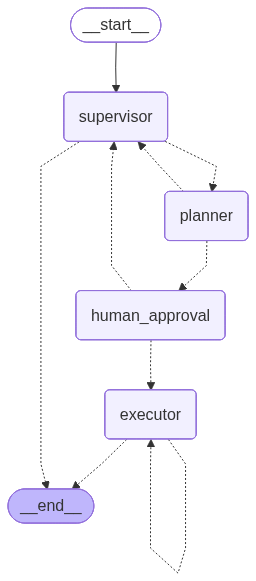

In [ ]:
from IPython.display import Image, display
graph = build_graph(context=context)
display(Image(graph.get_graph().draw_mermaid_png()))

# Testing: Visualizer

--- [Visualizer] Starting Step 3  at 1774404491.6846201)---
DEBUG: Prompt character count: 2064
message Execute step 3: Tenure vs Churn Analysis
Goal: Visualize how tenure months affect churn while accounting for segment reliability.
Expected output: Violin plot or KDE of tenure vs churn
{'messages': [HumanMessage(content='Execute step 3: Tenure vs Churn Analysis\nGoal: Visualize how tenure months affect churn while accounting for segment reliability.\nExpected output: Violin plot or KDE of tenure vs churn', additional_kwargs={}, response_metadata={}, id='9b64b032-ce88-4353-92da-54c1e9448294'), AIMessage(content='', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 889, 'total_tokens': 1040, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provi

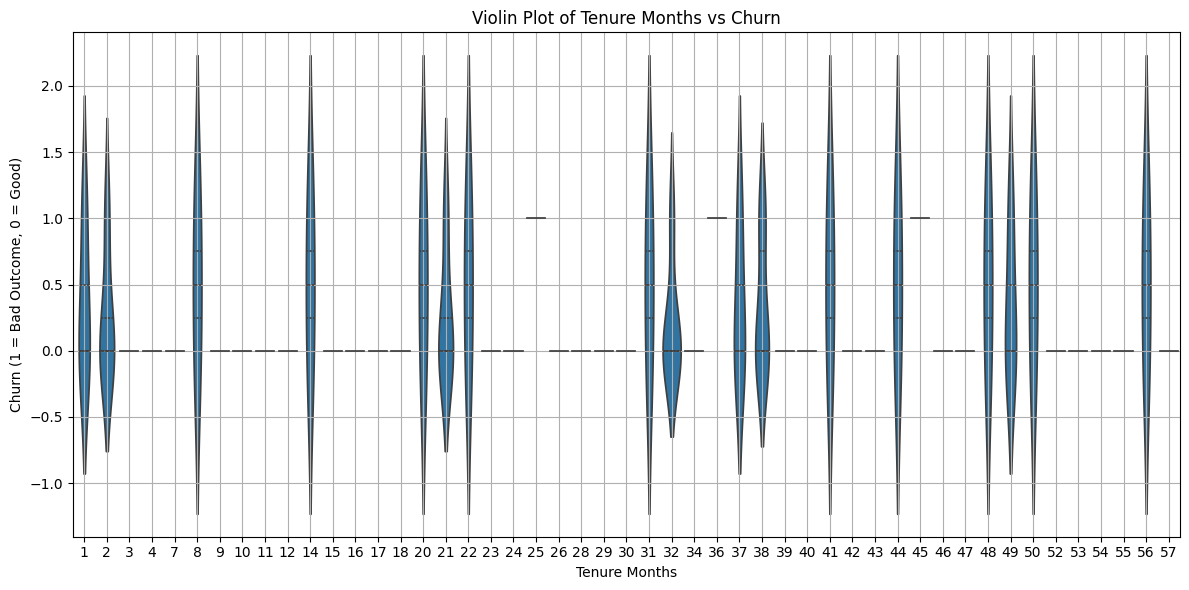

In [ ]:

from dotenv import load_dotenv
load_dotenv("config/.env")

from context import DatasetContext
from structured_outputs.planner_output import AnalysisStep
from structured_outputs.base import AgentType
from agents.visualizer_agent import run_visualizer

# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)

# Updated Step 3 with required fields
step_3 = AnalysisStep(
    id=3,
    title="Tenure vs Churn Analysis",
    description="Visualize how tenure months affect churn while accounting for segment reliability.",
    agent="visualizer",
    expected_output="Violin plot or KDE of tenure vs churn",
    # Add these missing required fields:
    inputs=["tenure_months", "churn", "plan_type"], 
    business_rule_notes="Exclude 'enterprise' due to small sample size per context."
)

prev_results = {
    2: {"summary": "Tenure is the strongest predictor of retention across all segments."}
}

# This will trigger the autonomous prompt and the create_chart tool
output = run_visualizer(step_3, context, prev_results)

print(f"Success: {output.success}")
print(f"Summary: {output.summary}")
print(f"Error: {output.error}")
if output.image_base64:
    print(f"Image (base64): {output.image_base64[:100]}...")  # Print a preview of the base64 string
    print("Static Image Generated.")
elif output.raw_result:
    print("Interactive Chart Data Generated.")

In [ ]:

from dotenv import load_dotenv
load_dotenv("config/.env")

from langgraph.types import Command

from context import DatasetContext
from workflow.state import AgentState
from workflow.graph import build_graph


# ── Shared context ────────────────────────────────────────────────────────────

context = DatasetContext(
    file_path="data/churn.csv",
    dataset_description=(
        "Monthly snapshot of active mobile subscribers Q3 2024. "
        "Each row is one customer account."
    ),
    column_descriptions={
        "churn":         "1 = churned (bad), 0 = retained",
        "arpu":          "Average revenue per user in USD",
        "tenure_months": "Months the customer has been active",
        "plan_type":     "Subscription tier: prepaid, postpaid, enterprise",
        "credits":       "Billing credits applied — high values indicate disputes",
    },
    business_rules=[
        "credits: high = bad — indicates billing disputes or service failures",
        "churn: 1 = bad outcome, 0 = good",
        "arpu: higher = better",
    ],
    known_issues=[
        "enterprise segment has only ~30 records — small sample",
    ]
)


def test_supervisor_to_planner():
    """
    Full flow: user question → supervisor → planner → human_approval interrupt.
    Verifies the graph pauses at human_approval with the plan.
    """
    print("\n" + "="*60)
    print("TEST 1 — Supervisor → Planner → Human approval interrupt")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-1"}}

    # Initial invocation
    original_question = "What is the churn rate by plan type?"
    print(f"\nOriginal question: {original_question}")

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    print(f"Result type: {type(result).__name__}")

    # Should have paused at human_approval
    if hasattr(result, "interrupts") and result.interrupts:
        interrupt_payload = result.interrupts[0].value

        # Show improved questions from state
        state_value = result.value if hasattr(result, "value") else {}
        improved = state_value.get("improved_questions", [])
        if improved:
            print(f"\nImproved question(s):")
            for i, q in enumerate(improved, 1):
                print(f"  {i}. {q}")

        print(f"\nInterrupted with: {interrupt_payload['message']}")
        plan_data = interrupt_payload.get("plan")
        if plan_data:
            print(f"Plan goal: {plan_data.get('goal')}")
            print(f"Steps: {len(plan_data.get('steps', []))}")
            for step in plan_data.get("steps", []):
                print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        print("✓ PASS — graph paused at human_approval")
    else:
        print(f"Result value: {result}")
        print("✗ FAIL — expected interrupt at human_approval")


def test_approve_and_execute():
    """
    Full flow including human approval and placeholder execution.
    """
    print("\n" + "="*60)
    print("TEST 2 — Approve plan and execute steps")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-2"}}

    # First invocation — runs to interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "What is the churn rate by plan type? Show as a bar chart."}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print("✗ FAIL — expected interrupt, got:", result)
        return

    print(f"Plan received — approving...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": result.interrupts[0].value.get("plan")}),
        config=config,
        version="v2",
    )

    print(f"Final result type: {type(final_result).__name__}")

    # Get final state
    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"Final report: {state.get('final_report')}")
        print(f"Step results: {state.get('step_results')}")
        if state.get("final_report"):
            print("✓ PASS — workflow completed")
        else:
            print("✗ FAIL — no final report")


def test_vague_question_clarification():
    """
    Vague question should trigger clarification — graph pauses at END
    waiting for user response.
    """
    print("\n" + "="*60)
    print("TEST 3 — Vague question triggers clarification")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-3"}}

    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": "analyse my data"}],
            "improved_question": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    state = result.value if hasattr(result, "value") else result
    if isinstance(state, dict):
        messages = state.get("messages", [])
        last_msg = messages[-1] if messages else None
        if last_msg:
            content = getattr(last_msg, "content", str(last_msg))
            print(f"Last message: {content}")
            print("✓ PASS — supervisor asked for clarification")

def test_full_pipeline_with_coder():
    """
    Full pipeline: question → supervisor → planner → human approval
    → coder executes steps → final report.
    """
    print("\n" + "="*60)
    print("TEST 4 — Full pipeline with coder agent")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-4"}}

    original_question = "What is the churn rate by plan type?"
    print(f"Original question: {original_question}")

    # First invocation — runs to human approval interrupt
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
            "planner_clarification": None,
        },
        config=config,
        version="v2",
    )

    if not hasattr(result, "interrupts") or not result.interrupts:
        print(f"✗ FAIL — expected interrupt: {result}")
        return

    plan_data = result.interrupts[0].value.get("plan", {})
    print(f"\nPlan goal: {plan_data.get('goal')}")
    print(f"Steps ({len(plan_data.get('steps', []))}):")
    for step in plan_data.get("steps", []):
        print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")

    print("\nApproving plan and executing...")

    # Resume with approval
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": plan_data}),
        config=config,
        version="v2",
    )

    state = final_result.value if hasattr(final_result, "value") else final_result
    if isinstance(state, dict):
        print(f"\nStep results:")
        for step_id, result_data in (state.get("step_results") or {}).items():
            if isinstance(result_data, dict):
                success = result_data.get("success", False)
                print(f"  Step {step_id}: {'✓' if success else '✗'}")
                if result_data.get("summary"):
                    print(f"    {result_data['summary'][:150]}...")

        final_report = state.get("final_report")
        if final_report:
            print(f"\nFinal report preview:\n{final_report[:400]}...")
            print("\n✓ PASS — full pipeline completed with coder")
        else:
            print("✗ FAIL — no final report produced")

def test_full_pipeline_with_visualizer():
    """
    TEST 5 — Full pipeline: supervisor → planner → human approval 
    → coder (calculation) → visualizer (plotting) → final report.
    """
    print("\n" + "="*60)
    print("TEST 5 — Full pipeline with Visualizer agent")
    print("="*60)

    graph = build_graph(context=context)
    config = {"configurable": {"thread_id": "test-thread-5-visualizer"}}

    original_question = "What is the churn rate by plan type? Show as a bar chart."
    print(f"Original question: {original_question}")

    # --- PHASE 1: Run to Human Approval ---
    result = graph.invoke(
        {
            "messages": [{"role": "user", "content": original_question}],
            "improved_questions": None,
            "plan": None,
            "human_approved": None,
            "current_step": None,
            "step_results": {},
            "final_report": None,
        },
        config=config,
        version="v2",
    )

    # 1. Access the tuple and get the first item
# result.interrupts is (Interrupt(value={...}),)
    if hasattr(result, "interrupts") and result.interrupts:
        first_interrupt = result.interrupts[0].value
        print(f"Interrupts: {first_interrupt}")
        # 2. NOW you can access the 'value' attribute
        payload = first_interrupt 

        # 3. Extract the plan dictionary
        plan_data = payload.get("plan", {})
        steps = plan_data.get("steps", [])
        
        print(f"✓ Successfully extracted plan with {len(steps)} steps.")
    else:
        print("✗ FAIL — No interrupts found.")
        return
    
    agents_in_plan = []
    for step in steps:
        print(f"  Step {step['id']} [{step['agent']}] — {step['title']}")
        agents_in_plan.append(step['agent'])

    # Validation: Ensure the planner assigned the visualizer
    if "visualizer" not in agents_in_plan:
        print("✗ FAIL — Planner did not assign the 'visualizer' agent for a chart request.")
        return
    print("✓ PASS — Planner correctly assigned Visualizer task.")

    # --- PHASE 2: Approve and Execute ---
    print("\nApproving plan and executing full flow...")

    # Resume with approval using the plan_data we just extracted
    final_result = graph.invoke(
        Command(resume={"approved": True, "plan": plan_data}),
        config=config,
        version="v2",
    )

    # Safely get state from v2 result
    state = final_result.value if hasattr(final_result, "value") else final_result
    
    if isinstance(state, dict):
        step_results = state.get("step_results") or {}
        visualizer_success = False

        print(f"\nStep results:")
        for step_id, res in step_results.items():
            # Find which agent ran this step to label the log correctly
            # Note: step_id from state might be a string or int depending on your implementation
            step_info = next((s for s in steps if str(s['id']) == str(step_id)), {})
            agent_name = step_info.get('agent', 'unknown')
            
            success = res.get("success", False)
            print(f"  Step {step_id} [{agent_name}]: {'✓' if success else '✗'}")

            # Check visualizer output for the recovered image
            if agent_name == "visualizer" and success:
                img_data = res.get("image_base64", "")
                if img_data and len(str(img_data)) > 100:
                    visualizer_success = True
                    print(f"    ✓ Image recovered ({len(str(img_data))} chars)")
                else:
                    print(f"    ✗ FAIL — Visualizer success but image_base64 is missing or too small.")

        final_report = state.get("final_report")
        if final_report and visualizer_success:
            print(f"\nFinal report preview:\n{final_report[:300]}...")
            print("\n✓ PASS — full pipeline completed: Supervisor → Planner → Coder → Visualizer")
        else:
            if not visualizer_success:
                print("✗ FAIL — Visualizer failed to produce an image.")
            if not final_report:
                print("✗ FAIL — No final report produced.")



if __name__ == "__main__":
    # test_supervisor_to_planner()
    # test_approve_and_execute()
    # test_vague_question_clarification()
    test_full_pipeline_with_visualizer()






TEST 5 — Full pipeline with Visualizer agent


NameError: name 'human_approval_node' is not defined